# Anzahl der Publikationen an niedersächsischen Hochschulen

Frage: Wie hoch ist das Publikationsvolumen je Hochschule in Niedersachsen?

Datenquellen:

    - OpenAlex: März 2026
    - OpenAlex (mit KB-Kodierung): Januar 2026
    - Scopus (mit KB-Kodierung): Oktober 2025

In [1]:
from google.cloud import bigquery
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

## Liste aller öffentlichen Hochschulen in Niedersachsen

In [4]:
liste_aller_hochschulen = client.query(f"""
                                        SELECT DISTINCT inst_name, dfg_inst_id, ror, sector, federal_state
                                        FROM `subugoe-collaborative.resources.inst_with_federal_state` AS f
                                        JOIN `subugoe-collaborative.openbib.kb_inst_lookup` AS kb
                                            ON CASE
                                                WHEN kb.inst_id = 621 THEN 'https://ror.org/03m2kj587'
                                                ELSE kb.ror 
                                            END = CONCAT('https://ror.org/', f.ror_id)
                                        LEFT JOIN UNNEST(current_sectors) AS sector
                                        WHERE federal_state = 'Niedersachsen' 
                                          AND sector IN ('uni', 'fh', 'khmh') 
                                          AND dfg_inst_id NOT IN (
                                            220269952, -- Fachhochschule für die Wirtschaft Hannover (FHDW)
                                            13033, -- PFH Private Hochschule Göttingen
                                            233118106, -- Leibniz-Fachhochschule
                                            198800578, -- Hochschule 21 Buxtehude
                                            195374963 -- Hochschule Weserbergland
                                          )
                                       """).to_dataframe()

In [5]:
liste_aller_hochschulen.loc[len(liste_aller_hochschulen)] = ['Norddeutsche Hochschule für Rechtspflege', '', 'https://ror.org/02743t710', 'fh', 'Niedersachsen']
liste_aller_hochschulen.replace(
    {'Hochschule für angewandte Wissenschaft und Kunst Hildesheim/Holzminden/Göttingen': 'HAWK Hochschule für angewandte Wissenschaft und Kunst'},
    inplace=True)
liste_aller_hochschulen.replace(
    {'https://ror.org/03z6vda50': 'https://ror.org/03m2kj587'},
    inplace=True)

In [6]:
liste_aller_hochschulen

,inst_name,dfg_inst_id,ror,sector,federal_state
0,Leuphana Universität Lüneburg,10232,https://ror.org/02w2y2t16,uni,Niedersachsen
1,Carl von Ossietzky Universität Oldenburg,10233,https://ror.org/033n9gh91,uni,Niedersachsen
2,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,10533,https://ror.org/02vvvm705,fh,Niedersachsen
3,Hochschule Emden/Leer,980710,https://ror.org/01bc76c69,fh,Niedersachsen
4,Gottfried Wilhelm Leibniz Universität Hannover,10238,https://ror.org/0304hq317,uni,Niedersachsen
5,"Hochschule für Musik, Theater und Medien Hannover",10246,https://ror.org/00x67m532,khmh,Niedersachsen
6,Hochschule Hannover,10252,https://ror.org/03m2kj587,fh,Niedersachsen
7,Stiftung Tierärztliche Hochschule Hannover,10249,https://ror.org/015qjqf64,uni,Niedersachsen
8,Medizinische Hochschule Hannover (MHH),10247,https://ror.org/00f2yqf98,uni,Niedersachsen
9,HAWK Hochschule für angewandte Wissenschaft un...,10253,https://ror.org/00f5q5839,fh,Niedersachsen


## Nur OpenAlex

In [38]:
oal = client.query(f"""
                    SELECT 
                        CASE 
                            WHEN inst.ror = 'https://ror.org/021ft0n22' THEN 'Georg-August-Universität Göttingen' -- UMG in GAU integrieren für Vergleichbarkeit
                            WHEN inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                            WHEN inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                            WHEN inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                            WHEN inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                            WHEN inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                            WHEN inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                            WHEN inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                            WHEN inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                            WHEN inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                            WHEN inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                            WHEN inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                            WHEN inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                            WHEN inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                            WHEN inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                            WHEN inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                            WHEN inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                            WHEN inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                            WHEN inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                            WHEN inst.ror = 'https://ror.org/02743t710' THEN 'Norddeutsche Hochschule für Rechtspflege'
                            ELSE ''
                        END AS inst_name,
                        COUNT(DISTINCT(doi)) AS n
                    FROM `subugoe-collaborative.openalex_walden.works` AS oal, UNNEST(authorships) AS aut, UNNEST(aut.institutions) AS inst
                    WHERE oal.type IN ('article', 'review') 
                        AND is_paratext=FALSE 
                        AND is_retracted=FALSE 
                        AND is_xpac=FALSE
                        AND publication_year BETWEEN 2020 AND 2024
                        AND inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111', -- Universität Vechta
                            'https://ror.org/02743t710' -- Norddeutsche Hochschule für Rechtspflege
                        )
                    GROUP BY inst_name
                    ORDER BY n DESC
                    """).to_dataframe()

In [39]:
oal

,inst_name,n
0,Georg-August-Universität Göttingen,21715
1,Medizinische Hochschule Hannover (MHH),15177
2,Gottfried Wilhelm Leibniz Universität Hannover,11662
3,Technische Universität Braunschweig,8608
4,Carl von Ossietzky Universität Oldenburg,6393
5,Universität Osnabrück,3350
6,Stiftung Tierärztliche Hochschule Hannover,2866
7,Leuphana Universität Lüneburg,2636
8,Technische Universität Clausthal,2148
9,Stiftung Universität Hildesheim,1204


## OpenAlex mit KB-Kodierung

In [9]:
kb = client.query(f"""
                    SELECT 
                        CASE 
                            WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen'
                            WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                            WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                            WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                            WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                            WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                            WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                            WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                            WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                            WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                            WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                            WHEN kb_inst.ror = 'https://ror.org/02743t710' THEN 'Norddeutsche Hochschule für Rechtspflege'
                            ELSE ''
                        END AS inst_name,
                        COUNT(DISTINCT(oal.doi)) AS n
                    FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                    JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                      ON inst.inst_id_top = kb_inst.inst_id
                    JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                        ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                    WHERE oal.type IN ('article', 'review') 
                        AND is_paratext=FALSE 
                        AND is_retracted=FALSE 
                        AND is_xpac=FALSE
                        AND publication_year BETWEEN 2020 AND 2024
                        AND kb_inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111', -- Universität Vechta
                            'https://ror.org/02743t710' -- Norddeutsche Hochschule für Rechtspflege
                        )
                    GROUP BY inst_name
                    ORDER BY n DESC
                    """).to_dataframe()

In [10]:
kb

,inst_name,n
0,Georg-August-Universität Göttingen,22372
1,Medizinische Hochschule Hannover (MHH),15138
2,Gottfried Wilhelm Leibniz Universität Hannover,11971
3,Technische Universität Braunschweig,8793
4,Carl von Ossietzky Universität Oldenburg,6589
5,Universität Osnabrück,3222
6,Stiftung Tierärztliche Hochschule Hannover,2592
7,Leuphana Universität Lüneburg,2285
8,Technische Universität Clausthal,2073
9,Stiftung Universität Hildesheim,976


## Scopus mit KB-Kodierung

In [13]:
import psycopg2 as pg
import os
from sqlalchemy import create_engine

In [15]:
host = os.environ['KB_HOST']
database = os.environ['KB_DATABASE']
user = os.environ['KB_USER']
pw = os.environ['KB_PASSWORD']
port = os.environ['KB_PORT']
engine = create_engine(f'postgresql://{user}:{pw}@{host}:{port}/{database}')

In [16]:
scp = pd.read_sql("""
                  SELECT 
                      CASE 
                        WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen'
                        WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                        WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                        WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                        WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                        WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                        WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                        WHEN kb_inst.inst_id = 621 THEN 'Hochschule Hannover'
                        WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                        WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                        WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                        WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                        WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                        WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                        WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                        WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                        WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                        WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                        WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                        WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                        WHEN kb_inst.ror = 'https://ror.org/02743t710' THEN 'Norddeutsche Hochschule für Rechtspflege'
                        ELSE ''
                        END AS inst_name,
                        COUNT(DISTINCT(doi)) AS n
                    FROM scp_b_202510.items AS scp
                    JOIN scp_b_202510.add_institution_kb_a AS kb_a
                        ON scp.item_id = kb_a.item_id
                    JOIN scp_b_202510.add_institution_lookup_kb_suppl AS kb_inst
                        ON kb_a.inst_id_top = kb_inst.inst_id
                    WHERE item_type && ARRAY['Review', 'Article']
                        AND pubyear BETWEEN 2020 AND 2024 
                        AND (kb_inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111', -- Universität Vechta
                            'https://ror.org/02743t710' -- Norddeutsche Hochschule für Rechtspflege
                        ) OR kb_inst.inst_id = 621)
                    GROUP BY inst_name
                    ORDER BY n DESC
                  """, 
                  con=engine)

In [17]:
scp

,inst_name,n
0,Georg-August-Universität Göttingen,19448
1,Medizinische Hochschule Hannover (MHH),11615
2,Gottfried Wilhelm Leibniz Universität Hannover,8851
3,Technische Universität Braunschweig,6532
4,Carl von Ossietzky Universität Oldenburg,5333
5,Stiftung Tierärztliche Hochschule Hannover,2518
6,Universität Osnabrück,2424
7,Leuphana Universität Lüneburg,1954
8,Technische Universität Clausthal,1616
9,Stiftung Universität Hildesheim,623


## Vergleich zwischen OpenAlex, OpenAlex(KB) und Scopus

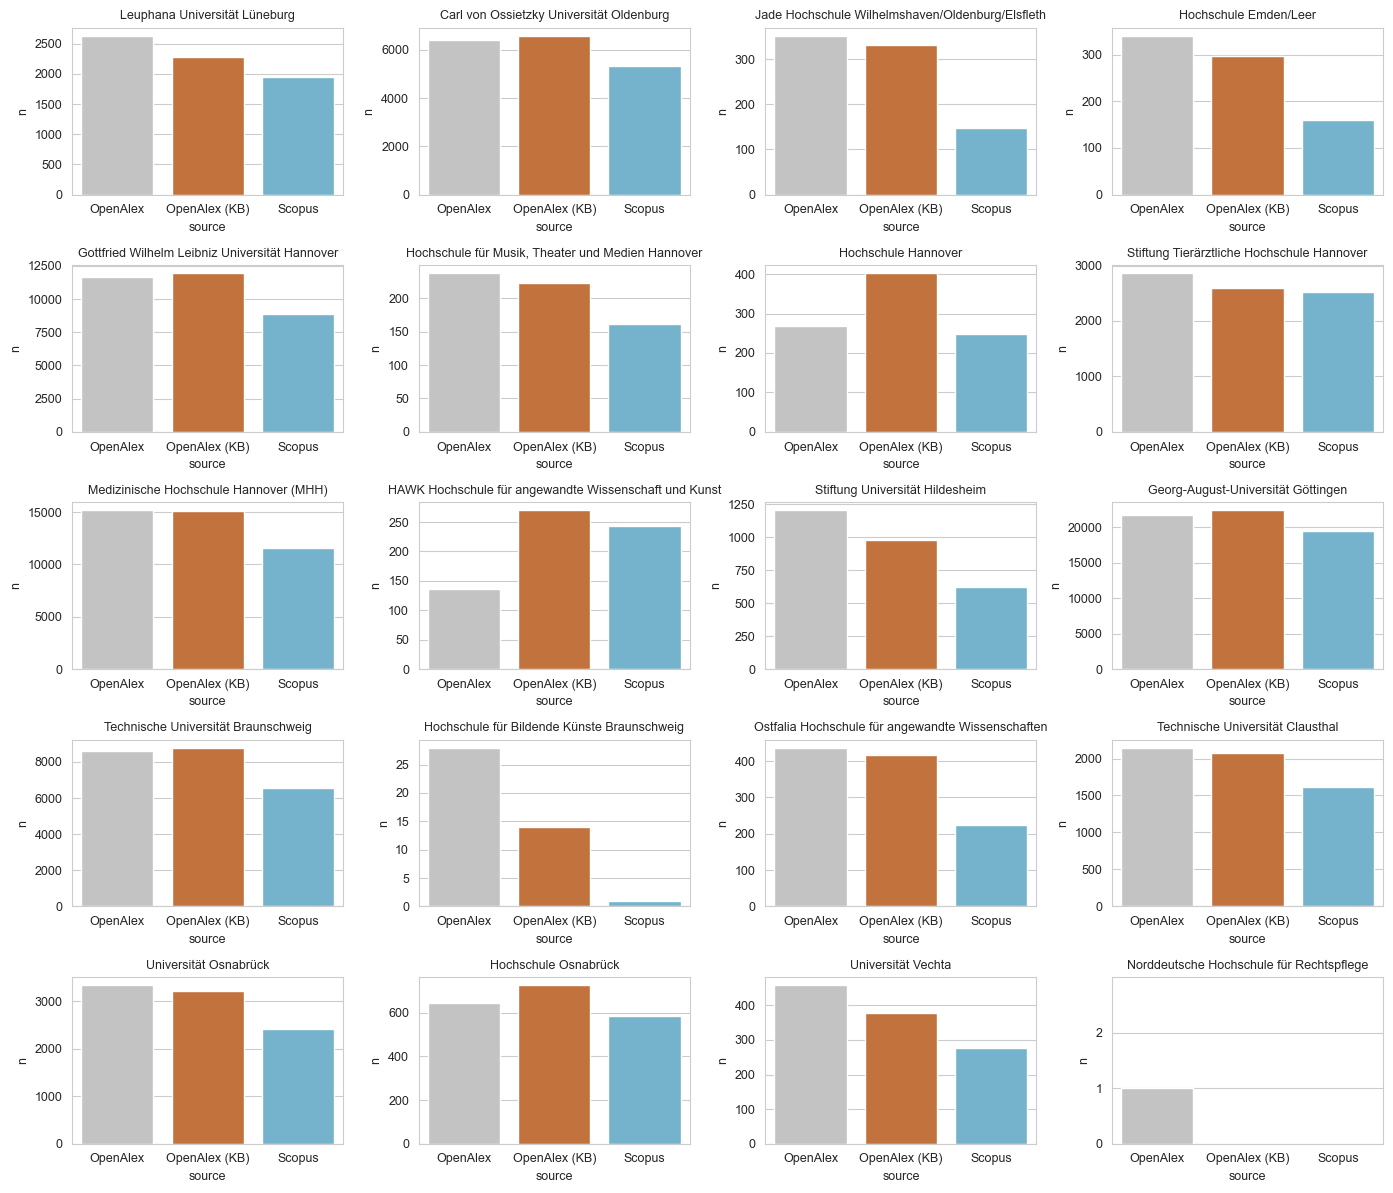

In [41]:
fig, axes = plt.subplots(nrows=5, 
                         ncols=4, 
                         sharex=False, 
                         sharey=False, 
                         figsize=(14,12))

axes = axes.reshape(-1)

for i, ax in enumerate(axes, 0):

    inst_name = liste_aller_hochschulen.iloc[i].inst_name

    oal_inst = oal[oal.inst_name == inst_name]
    kb_inst = kb[kb.inst_name == inst_name]
    scp_inst = scp[scp.inst_name == inst_name]

    oal_value = oal_inst.n.item()

    try:
        kb_value = kb_inst.n.item()
    except:
        kb_value = 0

    try:
        scp_value = scp_inst.n.item()
    except:
        scp_value = 0

    #if inst_name == 'Georg-August-Universität Göttingen':
    #    oal_value += oal[oal.inst_name == 'Universitätsmedizin Göttingen'].n.item()

    
    data = {
            'source': ['OpenAlex', 'OpenAlex (KB)', 'Scopus'],
            'n': [oal_value, kb_value, scp_value]
        }
    
    df = pd.DataFrame(data)
    
    sns.barplot(data=df, 
                x='source', 
                y='n', 
                hue='source',
                palette=['#c3c3c3', '#D86F27', '#65BADA'],
                ax=ax).set_title(inst_name, fontdict=dict(fontsize=9, fontweight=500))

    if inst_name == 'Norddeutsche Hochschule für Rechtspflege':
        ax.set_ylim(0,3)
        ax.set_yticks(range(0,3))

plt.tight_layout()

plt.show()

## Unterschied zwischen OpenAlex und KB-Kodierung

In [19]:
oal_kb = client.query(f"""
                        SELECT DISTINCT
                          kb.id AS kb_id, 
                          oal.id AS oal_id, 
                          kb.inst_name AS kb_name,
                          oal.inst_name AS oal_name,
                          kb.source AS kb_source, 
                          oal.source AS oal_source
                        FROM (
                          SELECT DISTINCT
                            CASE 
                              WHEN inst.ror = 'https://ror.org/021ft0n22' THEN 'Georg-August-Universität Göttingen' -- UMG in GAU integrieren für Vergleichbarkeit
                              WHEN inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                              WHEN inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                              WHEN inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                              WHEN inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                              WHEN inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                              WHEN inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                              WHEN inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                              WHEN inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                              WHEN inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                              WHEN inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                              WHEN inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                              WHEN inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                              WHEN inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                              WHEN inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                              WHEN inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                              WHEN inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                              WHEN inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                              WHEN inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                              WHEN inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                              WHEN inst.ror = 'https://ror.org/02743t710' THEN 'Norddeutsche Hochschule für Rechtspflege'
                              ELSE ''
                            END AS inst_name,
                            oal.id,
                            doi,
                            'OAL' AS source
                          FROM `subugoe-collaborative.openalex_walden.works` AS oal, UNNEST(authorships) AS aut, UNNEST(aut.institutions) AS inst
                          WHERE oal.type IN ('article', 'review') 
                            AND is_paratext=FALSE 
                            AND is_retracted=FALSE 
                            AND is_xpac=FALSE
                            AND publication_year BETWEEN 2020 AND 2024
                            AND inst.ror IN (
                                'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                                'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                                'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                                'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                                'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                                'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                                'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                                'https://ror.org/03m2kj587', -- Hochschule Hannover
                                'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                                'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                                'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                                'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                                'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                                'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                                'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                                'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                                'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                                'https://ror.org/04qmmjx98', -- Universität Osnabrück
                                'https://ror.org/059vymd37', -- Hochschule Osnabrück
                                'https://ror.org/045y6d111', -- Universität Vechta
                                'https://ror.org/02743t710' -- Norddeutsche Hochschule für Rechtspflege
                            )
                        ) AS oal
                        FULL OUTER JOIN (
                          SELECT DISTINCT
                            CASE 
                              WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen'
                              WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                              WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                              WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                              WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                              WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                              WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                              WHEN kb_inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                              WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                              WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                              WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                              WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                              WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                              WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                              WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                              WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                              WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                              WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                              WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                              WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                              WHEN kb_inst.ror = 'https://ror.org/02743t710' THEN 'Norddeutsche Hochschule für Rechtspflege'
                              ELSE ''
                            END AS inst_name,
                            oal.id,
                            oal.doi,
                            'KB' AS source
                        FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                        JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                        JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                            ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                        WHERE oal.type IN ('article', 'review') 
                            AND is_paratext=FALSE 
                            AND is_retracted=FALSE 
                            AND is_xpac=FALSE
                            AND publication_year BETWEEN 2020 AND 2024
                            AND kb_inst.ror IN (
                                'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                                'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                                'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                                'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                                'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                                'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                                'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                                'https://ror.org/03m2kj587', -- Hochschule Hannover
                                'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                                'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                                'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                                'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                                'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                                'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                                'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                                'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                                'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                                'https://ror.org/04qmmjx98', -- Universität Osnabrück
                                'https://ror.org/059vymd37', -- Hochschule Osnabrück
                                'https://ror.org/045y6d111', -- Universität Vechta
                                'https://ror.org/02743t710' -- Norddeutsche Hochschule für Rechtspflege
                            )
                        ) AS kb
                        ON oal.id = kb.id AND oal.inst_name = kb.inst_name
                    """).to_dataframe()

In [20]:
oal_kb.head()

,kb_id,oal_id,kb_name,oal_name,kb_source,oal_source
0,https://openalex.org/W3111330538,https://openalex.org/W3111330538,Hochschule Hannover,Hochschule Hannover,KB,OAL
1,None,https://openalex.org/W3142057900,None,Hochschule Hannover,None,OAL
2,None,https://openalex.org/W4402654889,None,HAWK Hochschule für angewandte Wissenschaft un...,None,OAL
3,https://openalex.org/W3200014410,https://openalex.org/W3200014410,Hochschule Emden/Leer,Hochschule Emden/Leer,KB,OAL
4,None,https://openalex.org/W4393350101,None,Hochschule Hannover,None,OAL


In [21]:
oal_kb.count()

kb_id         79760
oal_id        79379
kb_name       79760
oal_name      79379
kb_source     79760
oal_source    79379
dtype: int64

In [22]:
oal_kb[(~oal_kb.kb_source.isnull()) & (~oal_kb.oal_source.isnull())].count()

kb_id         75244
oal_id        75244
kb_name       75244
oal_name      75244
kb_source     75244
oal_source    75244
dtype: int64

In [23]:
oal_kb[(oal_kb.kb_source.isnull()) & (~oal_kb.oal_source.isnull())].count()

kb_id            0
oal_id        4135
kb_name          0
oal_name      4135
kb_source        0
oal_source    4135
dtype: int64

In [24]:
oal_kb[(~oal_kb.kb_source.isnull()) & (oal_kb.oal_source.isnull())].count()

kb_id         4516
oal_id           0
kb_name       4516
oal_name         0
kb_source     4516
oal_source       0
dtype: int64

In [37]:
oal_kb[(oal_kb.oal_name == 'Georg-August-Universität Göttingen') & (~oal_kb.oal_source.isnull())].groupby(['oal_name'])['oal_id'].count()

oal_name
Georg-August-Universität Göttingen    21912
Name: oal_id, dtype: int64

In [25]:
oal_kb[(oal_kb.kb_source.isnull()) & (~oal_kb.oal_source.isnull())].groupby(['oal_name'])['oal_id'].count()

oal_name
Carl von Ossietzky Universität Oldenburg                 271
Georg-August-Universität Göttingen                       849
Gottfried Wilhelm Leibniz Universität Hannover           531
HAWK Hochschule für angewandte Wissenschaft und Kunst     16
Hochschule Emden/Leer                                     48
Hochschule Hannover                                       94
Hochschule Osnabrück                                     128
Hochschule für Bildende Künste Braunschweig               24
Hochschule für Musik, Theater und Medien Hannover         19
Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth          23
Leuphana Universität Lüneburg                            361
Medizinische Hochschule Hannover (MHH)                   444
Norddeutsche Hochschule für Rechtspflege                   1
Ostfalia Hochschule für angewandte Wissenschaften         25
Stiftung Tierärztliche Hochschule Hannover               297
Stiftung Universität Hildesheim                          237
Technische Univ

In [26]:
oal_kb[(~oal_kb.kb_source.isnull()) & (oal_kb.oal_source.isnull())].groupby(['kb_name'])['kb_id'].count()

kb_name
Carl von Ossietzky Universität Oldenburg                  491
Georg-August-Universität Göttingen                       1494
Gottfried Wilhelm Leibniz Universität Hannover            845
HAWK Hochschule für angewandte Wissenschaft und Kunst     150
Hochschule Emden/Leer                                       4
Hochschule Hannover                                       228
Hochschule Osnabrück                                      212
Hochschule für Bildende Künste Braunschweig                10
Hochschule für Musik, Theater und Medien Hannover           4
Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth            2
Leuphana Universität Lüneburg                               8
Medizinische Hochschule Hannover (MHH)                    397
Ostfalia Hochschule für angewandte Wissenschaften           3
Stiftung Tierärztliche Hochschule Hannover                 16
Stiftung Universität Hildesheim                             3
Technische Universität Braunschweig                       492


In [27]:
oal_kb.groupby(['kb_source', 'oal_source', 'kb_name', 'oal_name'], dropna=False).count().reset_index()

,kb_source,oal_source,kb_name,oal_name,kb_id,oal_id
0,KB,OAL,Carl von Ossietzky Universität Oldenburg,Carl von Ossietzky Universität Oldenburg,6181,6181
1,KB,OAL,Georg-August-Universität Göttingen,Georg-August-Universität Göttingen,21063,21063
2,KB,OAL,Gottfried Wilhelm Leibniz Universität Hannover,Gottfried Wilhelm Leibniz Universität Hannover,11234,11234
3,KB,OAL,HAWK Hochschule für angewandte Wissenschaft un...,HAWK Hochschule für angewandte Wissenschaft un...,120,120
4,KB,OAL,Hochschule Emden/Leer,Hochschule Emden/Leer,297,297
5,KB,OAL,Hochschule Hannover,Hochschule Hannover,178,178
6,KB,OAL,Hochschule Osnabrück,Hochschule Osnabrück,522,522
7,KB,OAL,Hochschule für Bildende Künste Braunschweig,Hochschule für Bildende Künste Braunschweig,4,4
8,KB,OAL,"Hochschule für Musik, Theater und Medien Hannover","Hochschule für Musik, Theater und Medien Hannover",220,220
9,KB,OAL,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,332,332


In [28]:
diff = oal_kb.groupby(['kb_source', 'oal_source', 'kb_name', 'oal_name'], dropna=False).count().reset_index()

In [29]:
oal_kb[oal_kb.oal_id == 'https://openalex.org/W3114667184']

,kb_id,oal_id,kb_name,oal_name,kb_source,oal_source
51858,None,https://openalex.org/W3114667184,None,Medizinische Hochschule Hannover (MHH),None,OAL


In [30]:
oal_kb[oal_kb.kb_id == 'https://openalex.org/W3114667184']

,kb_id,oal_id,kb_name,oal_name,kb_source,oal_source
2854,https://openalex.org/W3114667184,None,Hochschule Hannover,None,KB,None


In [31]:
oal_kb[oal_kb.oal_id == 'https://openalex.org/W4400555163']

,kb_id,oal_id,kb_name,oal_name,kb_source,oal_source


In [32]:
oal_kb[oal_kb.kb_id == 'https://openalex.org/W4400555163']

,kb_id,oal_id,kb_name,oal_name,kb_source,oal_source
4147,https://openalex.org/W4400555163,None,Hochschule Hannover,None,KB,None


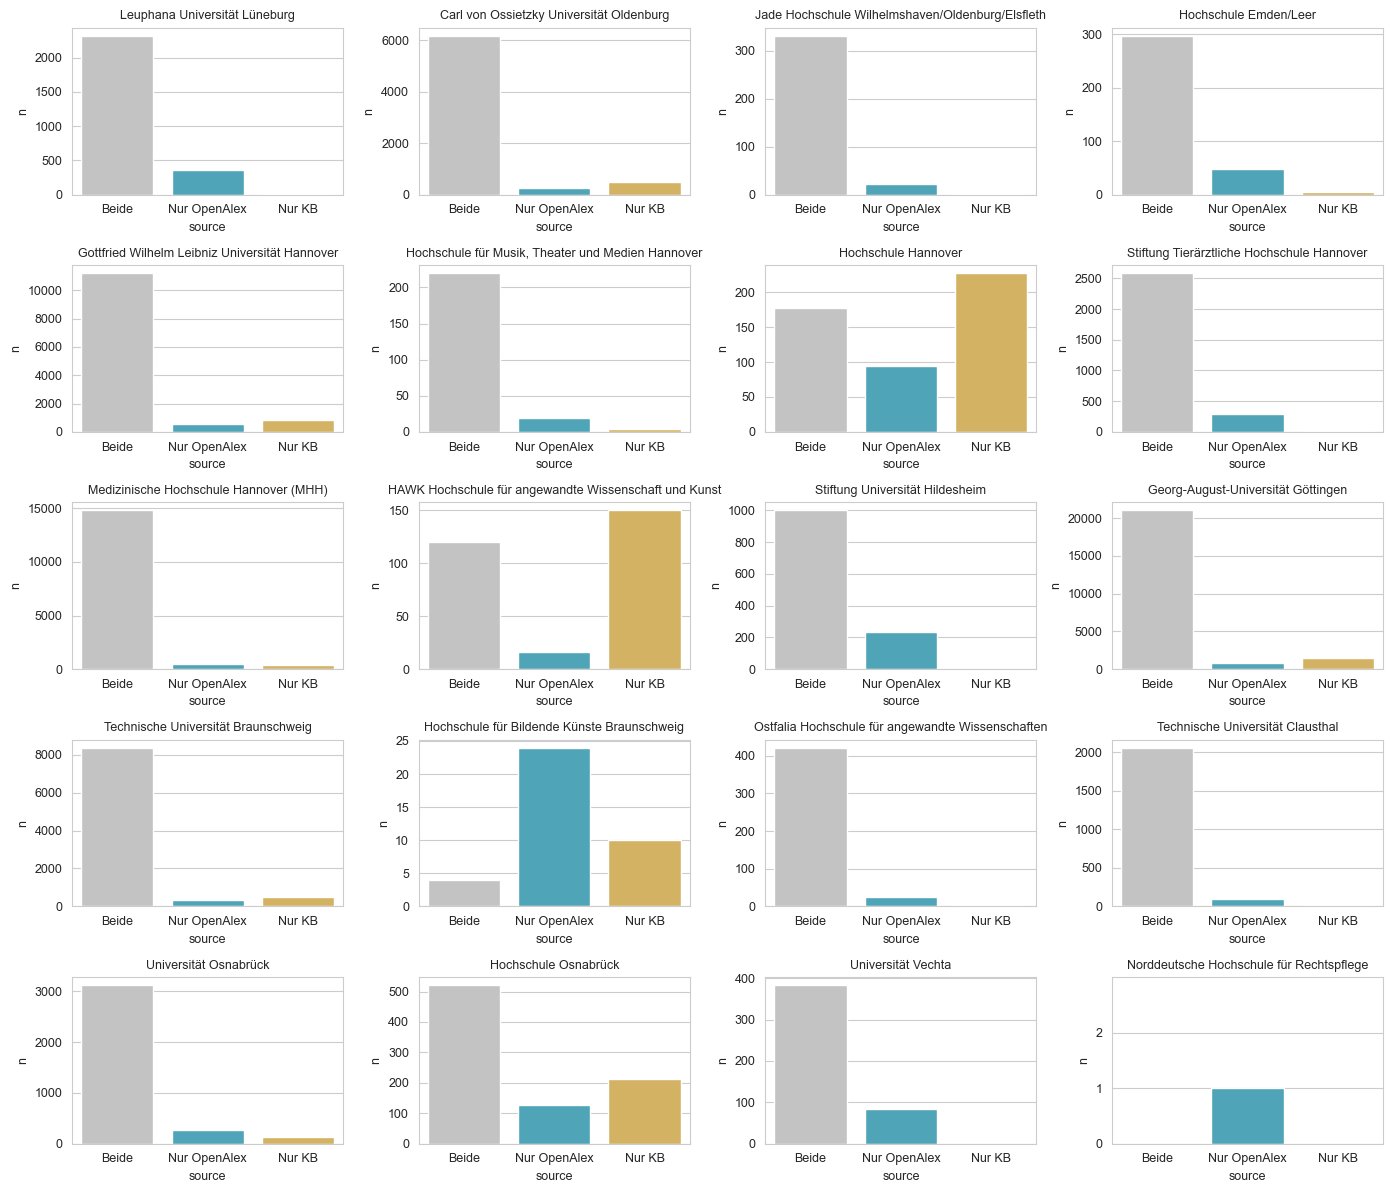

In [33]:
fig, axes = plt.subplots(nrows=5, 
                         ncols=4, 
                         sharex=False, 
                         sharey=False, 
                         figsize=(14,12))

axes = axes.reshape(-1)

for i, ax in enumerate(axes, 0):

    inst_name = liste_aller_hochschulen.iloc[i].inst_name

    df = diff[(diff.oal_name == inst_name) | (diff.kb_name == inst_name)]

    try:
        both = df[(~df.kb_source.isnull()) & (~df.oal_source.isnull())]['kb_id'].item()
    except:
        both = 0

    try:
        only_kb = df[(~df.kb_source.isnull()) & (df.oal_source.isnull())]['kb_id'].item()
    except:
        only_kb = 0

    try:
        only_oal = df[(df.kb_source.isnull()) & (~df.oal_source.isnull())]['oal_id'].item()
    except:
        only_oal = 0

    
    data = {
            'source': ['Beide', 'Nur OpenAlex', 'Nur KB'],
            'n': [both, only_oal, only_kb]
        }
    
    df = pd.DataFrame(data)
    
    sns.barplot(data=df, 
                x='source', 
                y='n', 
                hue='source',
                palette=['#c3c3c3', '#3EB1C8', '#E5BA52'],
                ax=ax).set_title(inst_name, fontdict=dict(fontsize=9, fontweight=500))

    if inst_name == 'Norddeutsche Hochschule für Rechtspflege':
        ax.set_ylim(0,3)
        ax.set_yticks(range(0,3))

plt.tight_layout()

plt.show()

In [34]:
oal_kb.groupby(['kb_source', 'oal_source', 'kb_name', 'oal_name'], dropna=False).count().reset_index().to_csv('oal_kb_2026_diff.csv', index=False)